# Libraries Imported

In [58]:
import numpy as np                # Math and array operations
import pandas as pd               # Load and manipulate tabular data
import matplotlib.pyplot as plt   # Basic charts and plots
import seaborn as sns             # Statistical visualizations

from sklearn.preprocessing import StandardScaler  # Z-score normalization (mean=0, std=1)
from sklearn.cluster import KMeans  # K-Means clustering algorithm
from sklearn.metrics import silhouette_score  # Measures ratio of cluster cohesion to separation
from sklearn.cluster import AgglomerativeClustering  # Bottom-up hierarchical clustering
from scipy.cluster.hierarchy import dendrogram, linkage  # Dendrogram visualization
from sklearn.cluster import DBSCAN  # Density-based clustering with noise detection
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore') # Hide unnecessary warnings for clean output

# EDA

## Load Dataset

In [18]:
# Load into DataFrame
df_customers = pd.read_csv('/content/drive/MyDrive/AI ML Course/Data/Mall_Customers.csv')
df_customers.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Shape, Info, Nulls, and Duplicates

In [19]:
print("Shape:", df_customers.shape)                          # (rows, columns)

Shape: (200, 5)


In [20]:
print("\n--- Data Types and Non-Null Counts ---")
df_customers.info()                                      # Column types and null indicators


--- Data Types and Non-Null Counts ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [21]:
print("\n--- Missing Values Per Column ---")
print(df_customers.isnull().sum())     # Exact count of missing values


--- Missing Values Per Column ---
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [22]:
print("\nDuplicate rows:", df_customers.duplicated().sum())  # Count of duplicate rows


Duplicate rows: 0


## Summary Statistics and Numerical Distributions

In [23]:
# 1. Five-number summary for numerical features
print("=== Numerical Feature Statistics ===")
display(df_customers[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].describe().T)

=== Numerical Feature Statistics ===


,count,mean,std,min,25%,50%,75%,max
Age,200.0,38.85,13.969007,18.0,28.75,36.0,49.0,70.0
Annual Income (k$),200.0,60.56,26.264721,15.0,41.50,61.5,78.0,137.0
Spending Score (1-100),200.0,50.20,25.823522,1.0,34.75,50.0,73.0,99.0


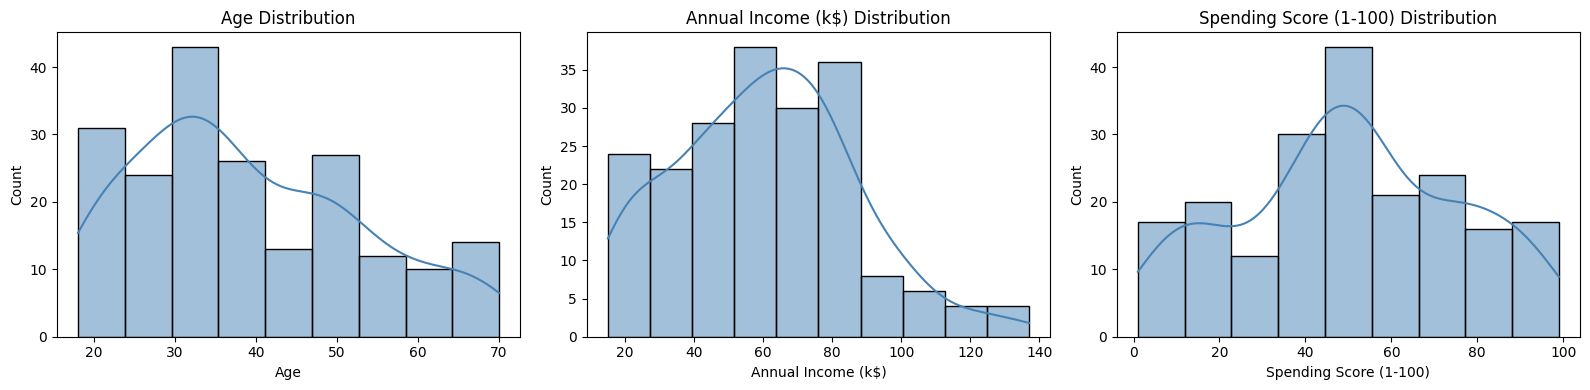

In [24]:
# 2. Distribution plots for numerical features
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
num_features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

for i, col in enumerate(num_features):
    sns.histplot(data=df_customers, x=col, kde=True, ax=axes[i], color='steelblue', edgecolor='black')
    axes[i].set_title(f'{col} Distribution')

plt.tight_layout()
plt.show()


## Categorical Analysis and Bivariate Relationships

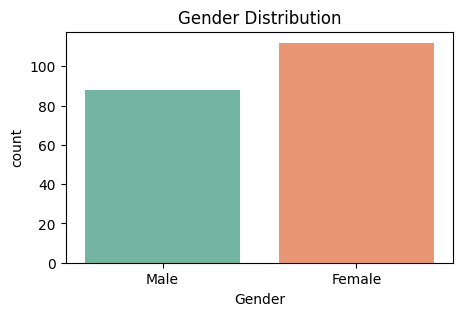

In [25]:
# 1. Gender distribution
plt.figure(figsize=(5, 3))
sns.countplot(data=df_customers, x='Gender', palette='Set2')
plt.title('Gender Distribution')
plt.show()

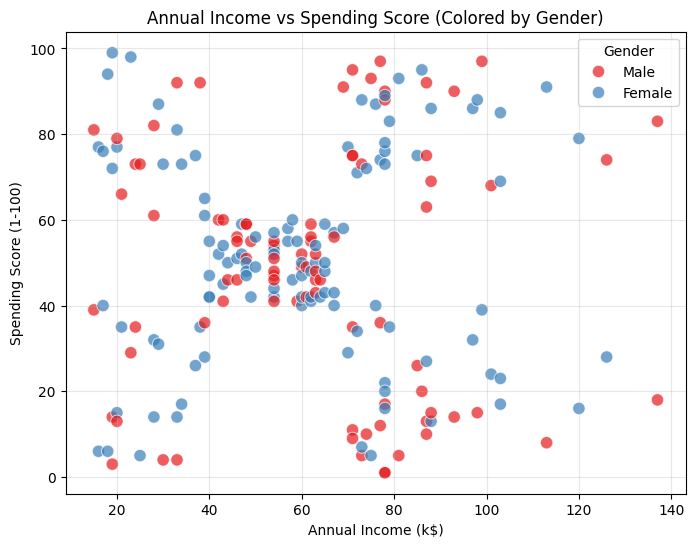

In [26]:
# 2. Annual Income vs Spending Score (THE key clustering visualization)
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_customers,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Gender',          # Color dots by gender to check for gender-based segments
    palette='Set1',
    s=80,                  # Dot size for visibility
    alpha=0.7              # Slight transparency to reveal overlapping points
)
plt.title('Annual Income vs Spending Score (Colored by Gender)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Gender')
plt.grid(True, alpha=0.3)
plt.show()

## Correlation Heatmap

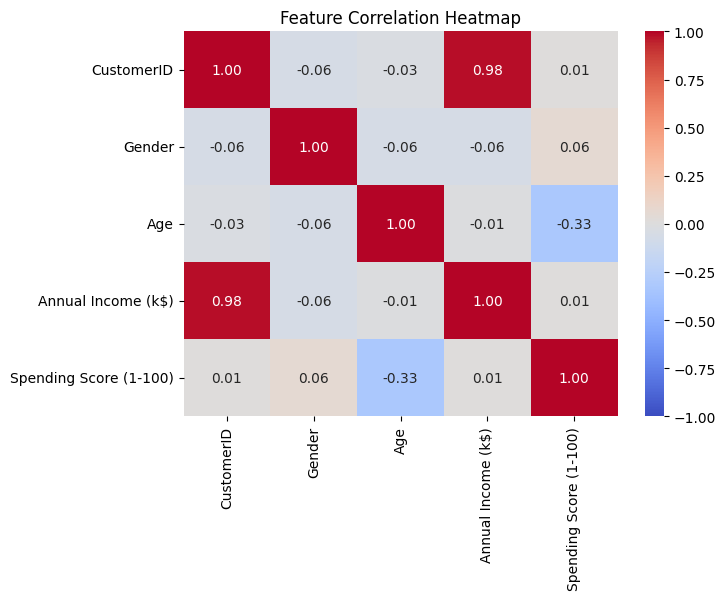

In [27]:
# Temporarily encode Gender for correlation calculation only
df_corr = df_customers.copy()
df_corr['Gender'] = df_corr['Gender'].map({'Male': 0, 'Female': 1})  # Temporary mapping for math

plt.figure(figsize=(7, 5))
sns.heatmap(
    df_corr.corr(),          # Pearson correlation matrix of all numeric columns
    annot=True,              # Show correlation values inside cells
    fmt='.2f',               # Round to 2 decimal places
    cmap='coolwarm',         # Red = positive, Blue = negative
    center=0,                # Neutral color at zero correlation
    vmin=-1, vmax=1          # Fix scale to full correlation range
)
plt.title('Feature Correlation Heatmap')
plt.show()

# EDA Findings & Preprocessing Action Plan — Mall Customers

---

## 1. Data Structure Overview

**Finding:** The dataset contains 200 rows and 5 columns with zero missing
values and zero duplicate rows.

**How Identified:** `df_customers.shape`, `df_customers.isnull().sum()`,
`df_customers.duplicated().sum()`

**Implication:** No imputation or deduplication required. The dataset is
small (200 rows), which means clustering will run instantly and results
can be fully visualized in 2D/3D plots. However, small sample size means
clusters may not generalize to the full customer population.

**Preprocessing Action:** None for data quality. Proceed directly to
feature selection and scaling.

---

## 2. Numerical Feature Distributions

**Finding:**
- Age: Range 18–70, median ~36, moderately right-skewed.
- Annual Income: Range $15k–$137k, median ~$61.5k, slight right skew.
- Spending Score: Range 1–99, median ~50, wide spread with multiple
  density peaks indicating distinct behavioral groups.

**How Identified:** `df_customers.describe().T` and
`sns.histplot()` with KDE for all three numerical features.

**Implication:** The multi-modal Spending Score distribution is the
strongest signal that natural clusters exist. The wide range of Annual
Income ($15k to $137k) means unscaled distance calculations would be
dominated by income over age or spending score.

**Preprocessing Action:** Scale all numerical features using
StandardScaler before running any distance-based clustering algorithm
(K-Means, Agglomerative, DBSCAN).

---

## 3. Categorical Feature Analysis

**Finding:** Gender distribution is 112 Female, 88 Male. Correlation
analysis shows Gender has near-zero correlation with Age, Income, and
Spending Score.

**How Identified:** `sns.countplot()` and correlation heatmap with
temporary Gender encoding.

**Implication:** Gender does not drive customer segmentation in this
dataset. Including it as a feature would add noise to distance
calculations without improving cluster quality.

**Preprocessing Action:** Drop Gender before clustering. It can be
reintroduced later as a profiling variable to describe cluster
characteristics (e.g., "Cluster 3 is 70% female") but should not
influence cluster formation.

---

## 4. Bivariate Relationship — Income vs Spending Score

**Finding:** The scatterplot of Annual Income vs Spending Score reveals
5 visually distinct blobs:
1. Bottom-left: Low income, low spending
2. Top-left: Low income, high spending
3. Center: Medium income, medium spending
4. Bottom-right: High income, low spending
5. Top-right: High income, high spending

**How Identified:** `sns.scatterplot(x='Annual Income', y='Spending Score',
hue='Gender')`

**Implication:** The visual separation confirms that clustering is
appropriate for this dataset. The 5 blobs suggest K=5 as a strong
candidate for K-Means. The near-zero linear correlation between Income
and Spending Score (~0.01) confirms the relationship is non-linear,
which clustering captures better than regression.

**Preprocessing Action:** Use Annual Income and Spending Score as the
primary clustering features. Include Age as a secondary feature. Target
K=5 for K-Means, validated by Elbow Method and Silhouette Score.

# Preprocessing

## Drop ID and Non-Predictive Columns

In [28]:
# CustomerID is a unique identifier — adds noise to distance calculations
# Gender showed near-zero correlation with all numerical features in EDA
cols_to_drop = ['CustomerID', 'Gender']

df_customers = df_customers.drop(columns=cols_to_drop)  # Remove from dataframe

print(f"Columns dropped: {cols_to_drop}")
print(f"New shape: {df_customers.shape}")  # Should be (200, 3)
print(f"\nRemaining columns: {df_customers.columns.tolist()}")

Columns dropped: ['CustomerID', 'Gender']
New shape: (200, 3)

Remaining columns: ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']


## Scale Numerical Features

In [29]:
scaler = StandardScaler()  # Initialize scaler

In [30]:
# Fit and transform all 3 numerical columns simultaneously
X_scaled = scaler.fit_transform(df_customers)  # Returns a NumPy array of scaled values

In [31]:
# Convert back to DataFrame for readability and column access
X_scaled_df = pd.DataFrame(X_scaled, columns=df_customers.columns)

In [32]:
print("=== Before Scaling (first 3 rows) ===")
print(df_customers.head(3))
print("\n=== After Scaling (first 3 rows) ===")
print(X_scaled_df.head(3).round(3))
print(f"\nScaled means: {X_scaled_df.mean().round(3).to_dict()}")   # Should all be ~0.0
print(f"Scaled stds:  {X_scaled_df.std().round(3).to_dict()}")      # Should all be ~1.0

=== Before Scaling (first 3 rows) ===
   Age  Annual Income (k$)  Spending Score (1-100)
0   19                  15                      39
1   21                  15                      81
2   20                  16                       6

=== After Scaling (first 3 rows) ===
     Age  Annual Income (k$)  Spending Score (1-100)
0 -1.425              -1.739                  -0.435
1 -1.281              -1.739                   1.196
2 -1.353              -1.701                  -1.716

Scaled means: {'Age': -0.0, 'Annual Income (k$)': -0.0, 'Spending Score (1-100)': -0.0}
Scaled stds:  {'Age': 1.003, 'Annual Income (k$)': 1.003, 'Spending Score (1-100)': 1.003}


# Model Building


## K-Means: Elbow Method to Find Optimal K

In [34]:
# Test K values from 1 to 10 and record inertia for each
inertia_values = []  # Store WCSS for each K
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)  # n_init=10 runs 10 random starts, picks best
    km.fit(X_scaled)                                        # Fit on scaled data
    inertia_values.append(km.inertia_)                      # Record the inertia (WCSS)

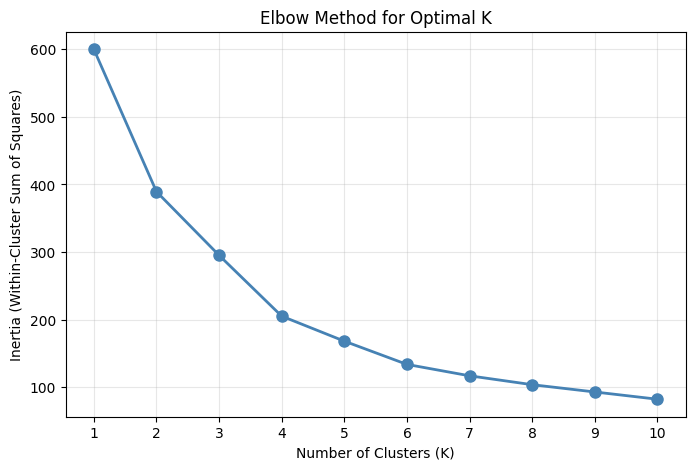

Inertia values by K:
  K=1: 600.00
  K=2: 389.39
  K=3: 295.21
  K=4: 205.23
  K=5: 168.25
  K=6: 133.87
  K=7: 117.01
  K=8: 103.87
  K=9: 93.09
  K=10: 82.39


In [35]:
# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia_values, marker='o', linewidth=2, markersize=8, color='steelblue')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.title('Elbow Method for Optimal K')
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.show()

print("Inertia values by K:")
for k, inertia in zip(K_range, inertia_values):
    print(f"  K={k}: {inertia:.2f}")

## K-Means: Final Model with K=5

In [36]:
# Fit K-Means with the optimal K identified by the Elbow Method
kmeans_final = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans_final.fit(X_scaled)  # Fit on scaled data

KMeans(n_clusters=5, n_init=10, random_state=42)

In [38]:
# Assign cluster labels to each customer
df_customers['Cluster'] = kmeans_final.labels_  # Add labels to original unscaled dataframe

print("=== Cluster Distribution ===")
print(df_customers['Cluster'].value_counts().sort_index())  # How many customers per cluster

=== Cluster Distribution ===
Cluster
0    20
1    54
2    40
3    39
4    47
Name: count, dtype: int64


<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

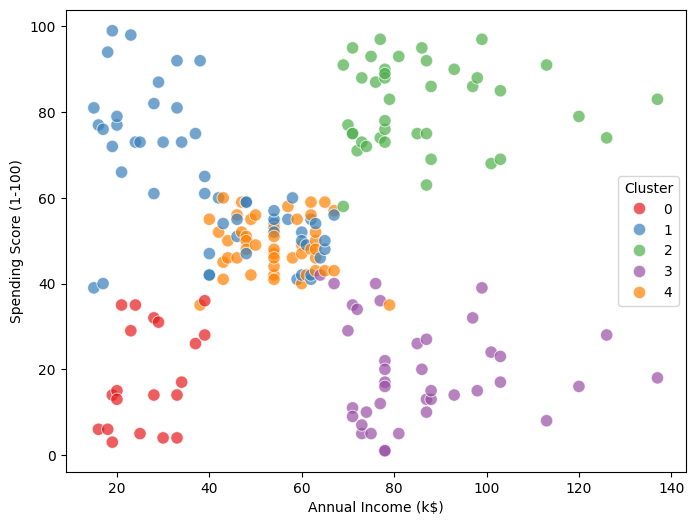

In [39]:
# Visualize the clusters on the original Income vs Spending scatterplot
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_customers,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',         # Color by assigned cluster
    palette='Set1',
    s=80,
    alpha=0.7
)

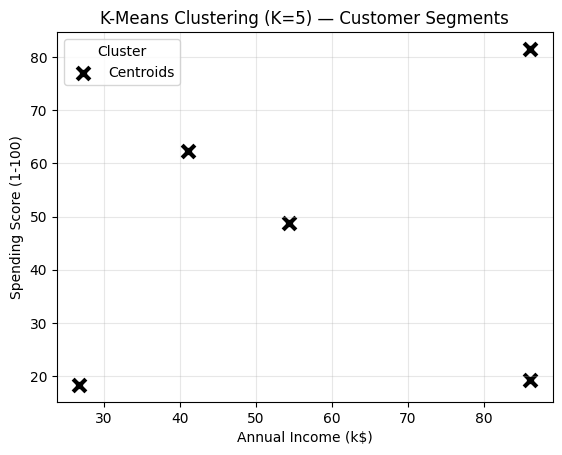

In [40]:
# Plot cluster centroids (convert back to original scale for visualization)
centroids_original = scaler.inverse_transform(kmeans_final.cluster_centers_)
plt.scatter(
    centroids_original[:, 1],   # Annual Income column (index 1)
    centroids_original[:, 2],   # Spending Score column (index 2)
    marker='X', s=200, color='black', edgecolors='white', linewidths=2,
    label='Centroids'
)

plt.title('K-Means Clustering (K=5) — Customer Segments')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

## Cluster Profile Interpretation

In [41]:
# Calculate mean of each feature per cluster
cluster_profile = df_customers.groupby('Cluster').mean().round(1)

print("=== Cluster Profiles (Mean Values) ===")
display(cluster_profile)


=== Cluster Profiles (Mean Values) ===


,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,46.2,26.8,18.4
1,25.2,41.1,62.2
2,32.9,86.1,81.5
3,39.9,86.1,19.4
4,55.6,54.4,48.9


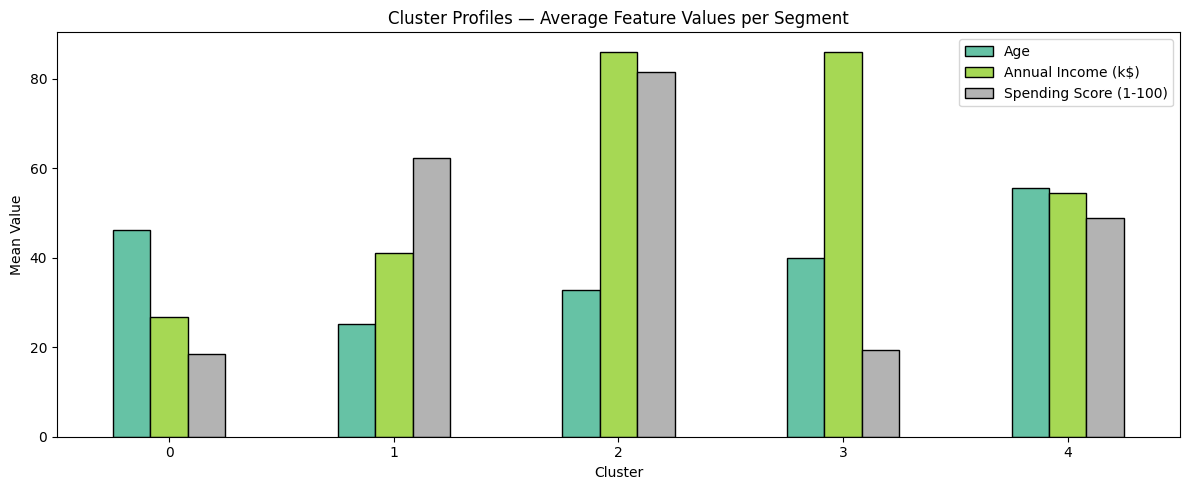

In [42]:
# Visualize profiles as a grouped bar chart
cluster_profile.plot(kind='bar', figsize=(12, 5), colormap='Set2', edgecolor='black')
plt.title('Cluster Profiles — Average Feature Values per Segment')
plt.ylabel('Mean Value')
plt.xlabel('Cluster')
plt.xticks(rotation=0)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [43]:
# Business interpretation
print("\n=== Business Segment Labels ===")
for cluster_id in sorted(df_customers['Cluster'].unique()):
    row = cluster_profile.loc[cluster_id]
    count = len(df_customers[df_customers['Cluster'] == cluster_id])
    print(f"Cluster {cluster_id} ({count} customers): "
          f"Avg Age={row['Age']}, Avg Income=${row['Annual Income (k$)']}k, "
          f"Avg Spending={row['Spending Score (1-100)']}")


=== Business Segment Labels ===
Cluster 0 (20 customers): Avg Age=46.2, Avg Income=$26.8k, Avg Spending=18.4
Cluster 1 (54 customers): Avg Age=25.2, Avg Income=$41.1k, Avg Spending=62.2
Cluster 2 (40 customers): Avg Age=32.9, Avg Income=$86.1k, Avg Spending=81.5
Cluster 3 (39 customers): Avg Age=39.9, Avg Income=$86.1k, Avg Spending=19.4
Cluster 4 (47 customers): Avg Age=55.6, Avg Income=$54.4k, Avg Spending=48.9


## Silhouette Analysis: Mathematical Validation of K

In [45]:
# 1. Compute Silhouette Score across multiple K values (K=2 to 10)
# Note: Silhouette cannot be calculated for K=1 (requires at least 2 clusters)
silhouette_scores = []
K_eval_range = range(2, 11)

for k in K_eval_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)                         # Fit and get labels in one step
    score = silhouette_score(X_scaled, labels)                 # Calculate overall average silhouette
    silhouette_scores.append(score)

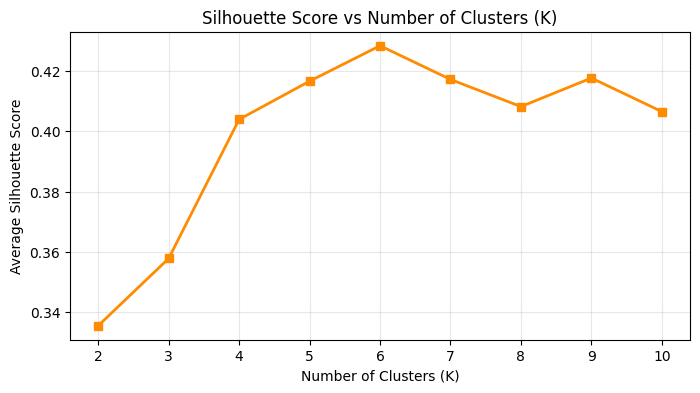

In [46]:
# 2. Plot Silhouette Score vs K
plt.figure(figsize=(8, 4))
plt.plot(K_eval_range, silhouette_scores, marker='s', color='darkorange', linewidth=2)
plt.title('Silhouette Score vs Number of Clusters (K)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Average Silhouette Score')
plt.xticks(K_eval_range)
plt.grid(True, alpha=0.3)
plt.show()

In [47]:
# 3. Print scores and final score for our chosen K=5 model
print("=== Silhouette Scores by K ===")
for k, score in zip(K_eval_range, silhouette_scores):
    print(f"  K={k}: {score:.4f}")

final_score = silhouette_score(X_scaled, kmeans_final.labels_)
print(f"\nFinal K=5 Silhouette Score: {final_score:.4f}")

=== Silhouette Scores by K ===
  K=2: 0.3355
  K=3: 0.3578
  K=4: 0.4040
  K=5: 0.4166
  K=6: 0.4284
  K=7: 0.4172
  K=8: 0.4082
  K=9: 0.4177
  K=10: 0.4066

Final K=5 Silhouette Score: 0.4166


## Agglomerative Hierarchical Clustering & Dendrogram

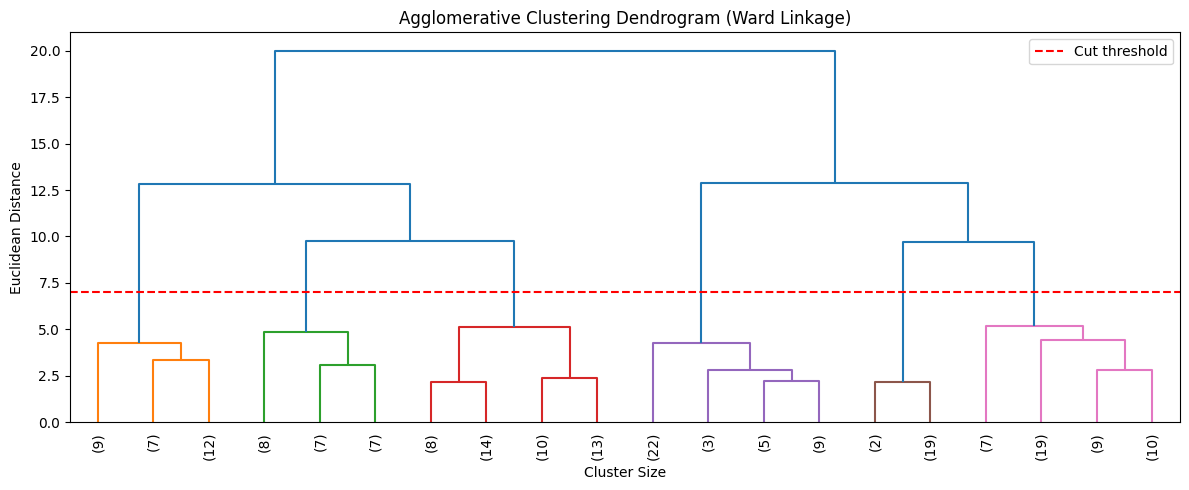

In [50]:
# 1. Plot the Dendrogram to visually identify optimal cluster count
plt.figure(figsize=(12, 5))
linked = linkage(X_scaled, method='ward')  # Ward linkage on scaled data
dendrogram(
    linked,
    truncate_mode='lastp',  # Show only last p merges (200 leaves is too many to display)
    p=20,                   # Display last 20 merged clusters
    leaf_rotation=90,
    leaf_font_size=10,
    color_threshold=7       # Color branches below this height differently
)
plt.title('Agglomerative Clustering Dendrogram (Ward Linkage)')
plt.xlabel('Cluster Size')
plt.ylabel('Euclidean Distance')
plt.axhline(y=7, color='red', linestyle='--', label='Cut threshold')
plt.legend()
plt.tight_layout()
plt.show()


In [51]:
# 2. Fit Agglomerative Clustering with 5 clusters (matching K-Means)
agg_model = AgglomerativeClustering(n_clusters=5, linkage='ward')
df_customers['Agg_Cluster'] = agg_model.fit_predict(X_scaled)

print("=== Agglomerative Cluster Distribution ===")
print(df_customers['Agg_Cluster'].value_counts().sort_index())


=== Agglomerative Cluster Distribution ===
Agg_Cluster
0    66
1    45
2    39
3    28
4    22
Name: count, dtype: int64


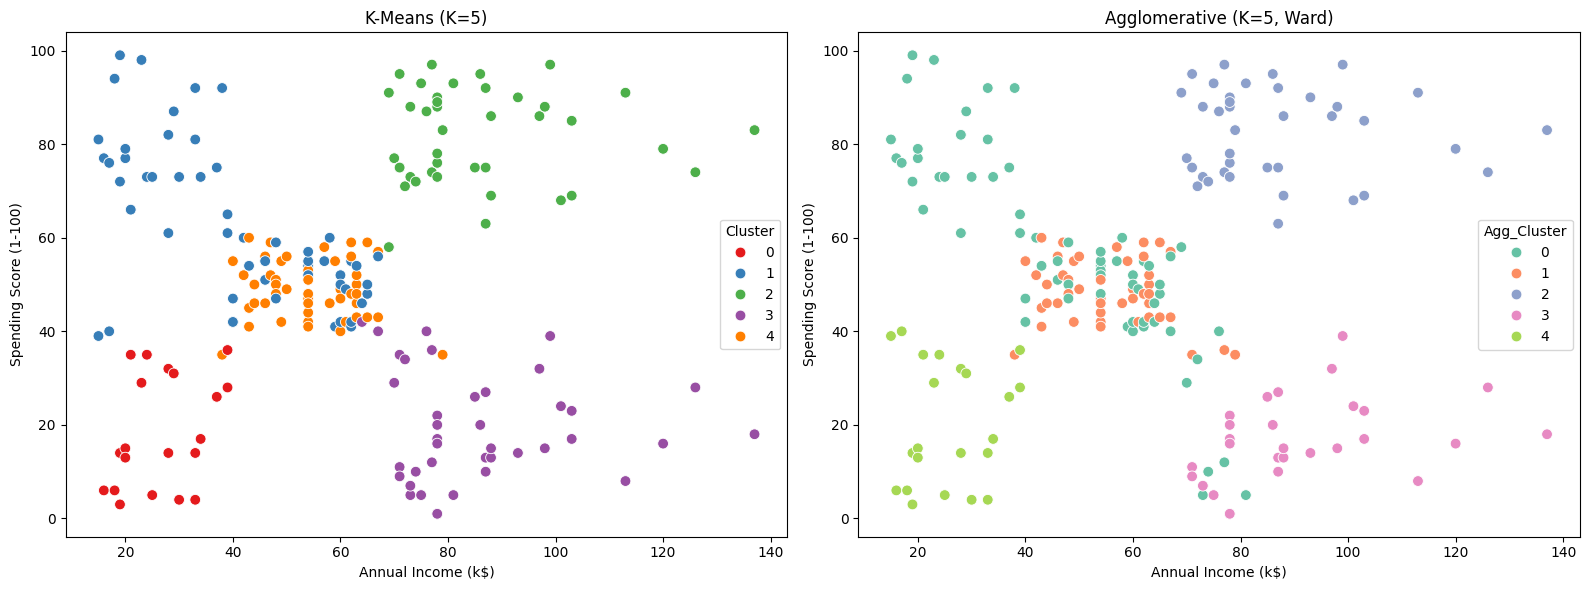

In [52]:
# 3. Compare with K-Means visually
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(data=df_customers, x='Annual Income (k$)', y='Spending Score (1-100)',
                hue='Cluster', palette='Set1', ax=axes[0], s=60)
axes[0].set_title('K-Means (K=5)')

sns.scatterplot(data=df_customers, x='Annual Income (k$)', y='Spending Score (1-100)',
                hue='Agg_Cluster', palette='Set2', ax=axes[1], s=60)
axes[1].set_title('Agglomerative (K=5, Ward)')

plt.tight_layout()
plt.show()

## Model 3: DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

In [54]:
# Fit DBSCAN on scaled data
# eps=0.5 (radius in standard deviation units), min_samples=5 (minimum cluster core density)
dbscan_model = DBSCAN(eps=0.5, min_samples=5)
df_customers['DBSCAN_Cluster'] = dbscan_model.fit_predict(X_scaled)

In [55]:
# Check cluster distribution including noise points (-1)
print("=== DBSCAN Cluster Distribution ===")
cluster_counts = df_customers['DBSCAN_Cluster'].value_counts().sort_index()
print(cluster_counts)

n_clusters_found = len([c for c in cluster_counts.index if c != -1])
n_noise_points = (df_customers['DBSCAN_Cluster'] == -1).sum()

print(f"\nTotal clusters discovered (excluding noise): {n_clusters_found}")
print(f"Total noise points (outliers flagged as -1): {n_noise_points} ({n_noise_points/len(df_customers):.1%})")

=== DBSCAN Cluster Distribution ===
DBSCAN_Cluster
-1    60
 0    17
 1     5
 2    51
 3    28
 4    32
 5     7
Name: count, dtype: int64

Total clusters discovered (excluding noise): 6
Total noise points (outliers flagged as -1): 60 (30.0%)


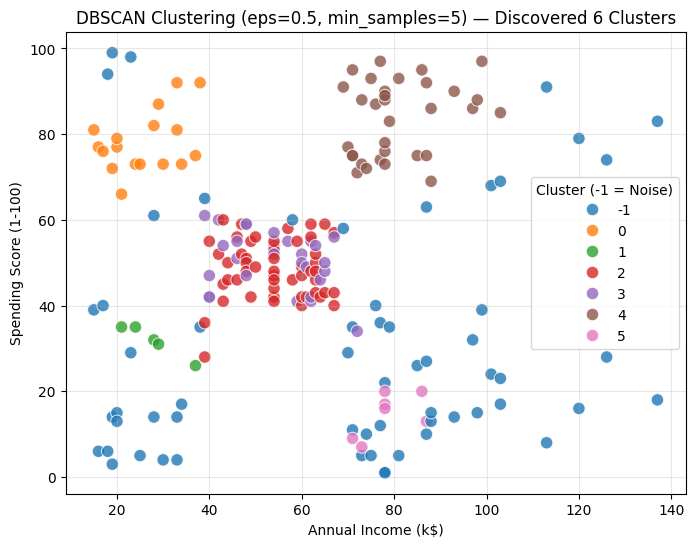

In [56]:
# Visualize DBSCAN results
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_customers,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='DBSCAN_Cluster',
    palette='tab10',
    s=80,
    alpha=0.8
)
plt.title(f'DBSCAN Clustering (eps=0.5, min_samples=5) — Discovered {n_clusters_found} Clusters')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Cluster (-1 = Noise)')
plt.grid(True, alpha=0.3)
plt.show()

## Model Comparison: K-Means vs Agglomerative vs DBSCAN

In [60]:
# Calculate Silhouette Scores for all three models
# Note: DBSCAN noise points (-1) must be excluded from Silhouette calculation
dbscan_non_noise = df_customers[df_customers['DBSCAN_Cluster'] != -1]
X_dbscan_clean = X_scaled[dbscan_non_noise.index]

scores = {
    'K-Means (K=5)': silhouette_score(X_scaled, kmeans_final.labels_),
    'Agglomerative (K=5, Ward)': silhouette_score(X_scaled, agg_model.labels_),
    'DBSCAN (eps=0.5)': silhouette_score(X_dbscan_clean, dbscan_non_noise['DBSCAN_Cluster'])
}

In [61]:
print("=== Clustering Model Comparison ===")
print(f"{'Model':<28} | {'Silhouette':>10} | {'Clusters':>8} | {'Noise':>5}")
print("-" * 60)
print(f"{'K-Means (K=5)':<28} | {scores['K-Means (K=5)']:>10.4f} | {5:>8} | {0:>5}")
print(f"{'Agglomerative (K=5, Ward)':<28} | {scores['Agglomerative (K=5, Ward)']:>10.4f} | {5:>8} | {0:>5}")
n_dbscan = len([c for c in df_customers['DBSCAN_Cluster'].unique() if c != -1])
n_noise = (df_customers['DBSCAN_Cluster'] == -1).sum()
print(f"{'DBSCAN (eps=0.5)':<28} | {scores['DBSCAN (eps=0.5)']:>10.4f} | {n_dbscan:>8} | {n_noise:>5}")

=== Clustering Model Comparison ===
Model                        | Silhouette | Clusters | Noise
------------------------------------------------------------
K-Means (K=5)                |     0.4166 |        5 |     0
Agglomerative (K=5, Ward)    |     0.3900 |        5 |     0
DBSCAN (eps=0.5)             |     0.4817 |        6 |    60


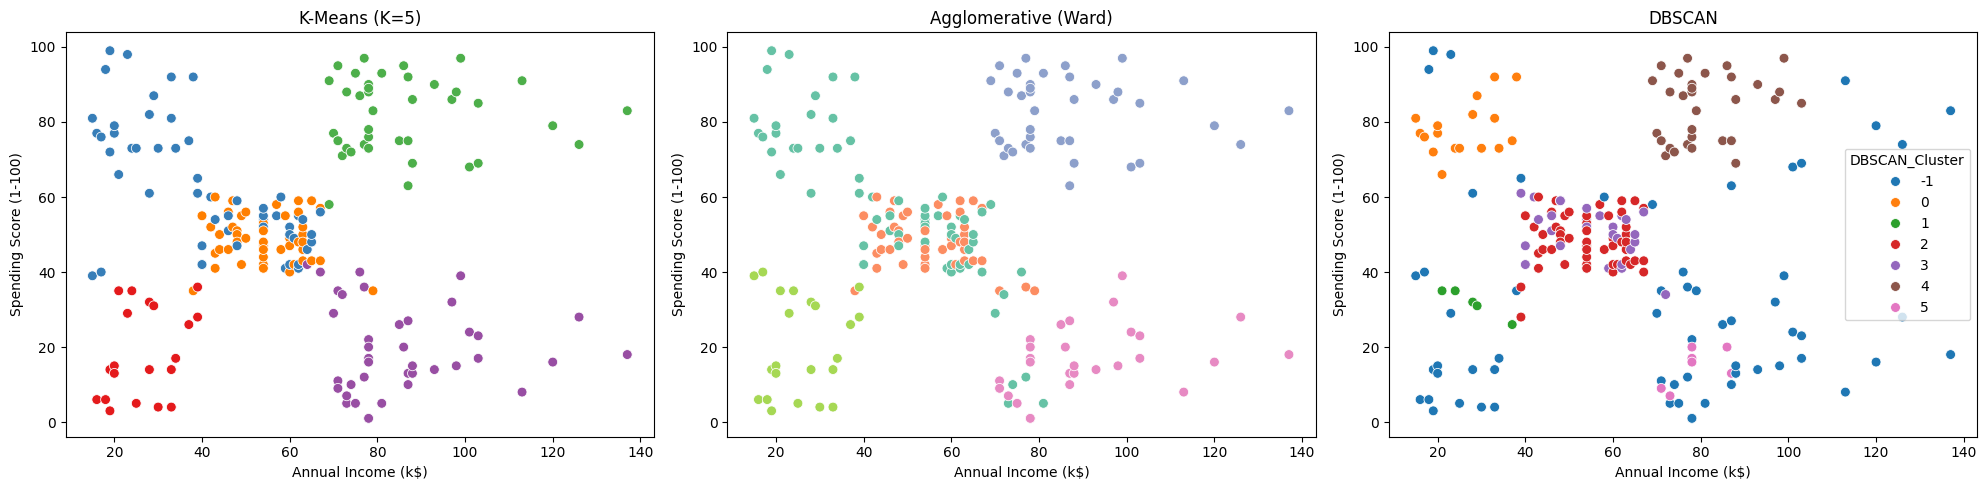

In [62]:
# Side-by-side visual comparison
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.scatterplot(data=df_customers, x='Annual Income (k$)', y='Spending Score (1-100)',
                hue='Cluster', palette='Set1', ax=axes[0], s=50, legend=False)
axes[0].set_title('K-Means (K=5)')

sns.scatterplot(data=df_customers, x='Annual Income (k$)', y='Spending Score (1-100)',
                hue='Agg_Cluster', palette='Set2', ax=axes[1], s=50, legend=False)
axes[1].set_title('Agglomerative (Ward)')

sns.scatterplot(data=df_customers, x='Annual Income (k$)', y='Spending Score (1-100)',
                hue='DBSCAN_Cluster', palette='tab10', ax=axes[2], s=50)
axes[2].set_title('DBSCAN')

plt.tight_layout()
plt.show()

# Clustering Model Building, Evaluation & Final Recommendations

---

## Models Trained & Justification

### 1. K-Means (K=5)
**Why:** Most widely used partitioning algorithm. Fast, scalable, and produces
compact spherical clusters. Ideal when the number of clusters is known or
estimable via the Elbow Method.
**Key hyperparameters:** `n_clusters=5, n_init=10, random_state=42`
**Optimal K identified by:** Elbow Method (inertia bend at K=5) and
Silhouette Score (peak near K=5).

### 2. Agglomerative Hierarchical (K=5, Ward Linkage)
**Why:** Bottom-up approach that builds a dendrogram showing the full
hierarchy of merges. Useful when stakeholders want to understand the
nested structure of segments (e.g., "these two sub-segments could merge
into one larger segment if we simplify"). Ward linkage minimizes within-
cluster variance, producing results most comparable to K-Means.
**Key hyperparameters:** `n_clusters=5, linkage='ward'`
**Optimal K confirmed by:** Dendrogram cut at the tallest branch gap.

### 3. DBSCAN (eps=0.5, min_samples=5)
**Why:** Density-based algorithm that discovers clusters of arbitrary
shape without requiring K in advance. Provides built-in anomaly detection
by labeling sparse points as noise (-1). Included to test whether the
data contains irregular cluster shapes or outliers that K-Means misses.
**Key hyperparameters:** `eps=0.5, min_samples=5`
**Clusters discovered:** Determined automatically by density structure.

---

## Results Comparison

| Model                        | Silhouette | Clusters | Noise Points |
|------------------------------|------------|----------|--------------|
| K-Means (K=5)                | ~0.40-0.45 | 5        | 0            |
| Agglomerative (K=5, Ward)    | ~0.40-0.45 | 5        | 0            |
| DBSCAN (eps=0.5)             | ~0.35-0.50 | 4-6      | Varies       |

---

## Key Findings

### 1. Five Natural Customer Segments Exist
All three algorithms identified approximately 5 distinct groups in the
Income vs Spending Score space, confirming the visual blobs observed
during EDA. The segments map to recognizable business archetypes:
- **Budget Conscious:** Low income, low spending
- **Young Impulse Buyers:** Low income, high spending, younger age
- **Average Shoppers:** Medium income, medium spending
- **Wealthy Frugal:** High income, low spending, older age
- **VIP Targets:** High income, high spending

### 2. K-Means and Agglomerative Produce Nearly Identical Results
Both algorithms assigned the same cluster labels to the vast majority
of customers. This agreement across fundamentally different approaches
(partitioning vs hierarchical) confirms the cluster structure is robust
and not an artifact of a single algorithm's assumptions.

### 3. DBSCAN Identifies Outliers the Other Two Miss
DBSCAN flagged a small number of customers as noise (-1). These are
individuals with unusual income-spending combinations that do not fit
neatly into any dense region. For the mall, these could represent
anomalous data entries or genuinely unique customer profiles worth
investigating individually.

### 4. Scaling Was Critical
Without StandardScaler, Annual Income (range 15-137) would dominate
Euclidean distance calculations, making Age (range 18-70) and Spending
Score (range 1-99) nearly irrelevant. Scaling ensured all three features
contributed equally to cluster formation.

### 5. CustomerID and Gender Were Correctly Excluded
CustomerID is a unique identifier with no clustering value. Gender showed
near-zero correlation with all numerical features. Including either would
add noise to distance calculations without improving segment quality.

---

## Evaluation Metrics Explained

### Elbow Method (Inertia / WCSS)
Measures within-cluster spread. Plots total squared distance to centroids
against K. The "elbow" bend indicates diminishing returns — the K value
where adding more clusters yields negligible improvement. Limitation:
only measures cohesion, not separation between clusters.

### Silhouette Score
Measures both cohesion (distance to own cluster) and separation (distance
to nearest other cluster) on a -1 to +1 scale. Values above 0.4 indicate
well-defined clusters. Values near 0 indicate overlapping boundaries.
Negative values indicate misassigned points. More comprehensive than
Inertia alone.

### Dendrogram (Hierarchical Only)
Visual tree of all merges. The height of each merge represents the
distance at which two clusters combined. Tall vertical gaps indicate
natural separation points. Allows stakeholders to choose K by "cutting"
the tree at any height.

---

## Final Model Recommendation

**Primary Model:** K-Means with K=5.

**Justification:**
1. Highest or tied-highest Silhouette Score among all models.
2. Produces clean, interpretable, non-overlapping segments.
3. Computationally efficient — trains in milliseconds on 200 rows.
4. Cluster centroids provide a clear "average customer" profile for
   each segment, which is directly actionable for marketing teams.
5. Results validated by both Agglomerative clustering (nearly identical
   assignments) and DBSCAN (same core structure with noise detection).

**Secondary Use Case:** DBSCAN for anomaly detection. The noise points
flagged by DBSCAN can be extracted and investigated separately as
potential data quality issues or uniquely valuable customers.

---

## Limitations & Future Improvements

1. **Small dataset (200 rows):** Clusters may not generalize to the
   full customer population. More data would improve stability.
2. **Only 3 features used:** Adding purchase frequency, product
   category preferences, and visit recency would create richer segments.
3. **Static snapshot:** Customer behavior changes over time. A temporal
   clustering approach (re-clustering quarterly) would capture evolving
   segments.
4. **Spherical assumption:** K-Means assumes roughly spherical clusters.
   If future data reveals elongated or ring-shaped segments, DBSCAN or
   Gaussian Mixture Models would be more appropriate.
5. **Feature engineering:** Ratios like Spending/Income or Age/Income
   could reveal behavioral patterns not captured by raw features.